# From Dying to Liberation or Rebirth: A Python Analysis of Tibetan Buddhist Bardo Texts

## Project Introduction

This project explores how key concepts related to death, bardo, rebirth, awareness, and liberation appear in Buddhist texts about dying and the bardos collection from Lotsawa House. In Tibetan Buddhist thought, people see death as a transitional process in which consciousness continues through different intermediate states. These ideas make the bardo a useful topic for digital text analysis, because the texts often connect death with many other religious concepts, such as mind, recognition, clear light, karma, samsara, and liberation.

The goal of this project is to use computational methods to examine the vocabulary structure of the “Dying and the Bardos” texts. Instead of reading the texts only through close reading, this project uses word frequency analysis, thematic keyword frequency, and co-occurrence network analysis to identify repeated patterns. These methods help show which concepts are most central in the dataset and which ideas often appear together.


## Research Question

This project asks how selected Tibetan Buddhist bardo texts desrcribe the transition from dying to liberation or rebirth. My main research question is:

 *How do seleted Tibetan Buddhist bardo texts connect dying, awareness, liberation, and rebirth?*

To answer this question, I use word frequency analysis and co-occurrence network analysis. First, I examine which words appear most frequently in the dataset. I pay special attention to words related to death and transition, such as "death," "dying," "bardo," "intermediate," and "becoming." I also look at words related to spritual possibility, such as "awareness," "mind," "clear light," "liberation," and "rebirth."

Second, I ask which of these words appear together in the same sections of the text. This helps me understand whether bardo is described mainly as a state after death, or as a process that connects dying with recognition, liberation, and rebirth. For example, if words such as "dying,""awareness," and "liberation" often appear together, this may suggest that the text present death as a moment when spiritual recognition is possible. If words such as "bardo," "becoming," and "rebirth" appear together, this may suggest that the texts also describe bardo as a transition toward another life.

This project focuses on a small dataset of selected bardo-related text. The goal is to use Python to identify patterns in the language of these texts, and then interpret those patterns through close reading. In this way, the project uses computational analysis as a starting point for understanding how bardo is represented as a space betwwen death, liberation, and rebirth.

## Data Source

The data for this project comes from the [“Dying and the Bardos” topic page on Lotsawa House](https://www.lotsawahouse.org/topics/dying-bardos/).

Lotsawa House is a website that provides Tibetan Buddhist texts in translation. It describes itself as “The Home of Tibetan Buddhist Texts in Translation,” and its “Dying and the Bardos” page collects texts related to the process of dying and the intermediate states, or bardos. 

For this project, I collected the English texts listed under this topic page and organized them into a structured dataset. Each row in the dataset represents one section of text. The dataset includes columns such as `id`, `title`, `section_keyword`, `text`, and `cleaned_text`.

The main column used for analysis is `cleaned_text`. This column contains the processed version of the original text. Before analysis, I cleaned the text by converting words to lowercase and preparing the text for keyword counting and co-occurrence analysis. This step makes the text more consistent, so that words such as “Death” and “death” can be counted together.

This source focuses specifically on Buddhist teachings about dying, bardo states, rebirth, awareness, and liberation. However, the dataset is also limited because it comes from one website and one selected topic collection. Therefore, the results of this project should be understood as patterns within the Lotsawa House “Dying and the Bardos” collection.

## Load Dataset

In this section, I load the dataset for my project. The dataset is stored as a CSV file named `bardo_data.cvs`. Each row represents one section of a ztibetan Buddhist bardo-related text from Lostsawa House. The mean text for analysis is stored in the `text` column.

The dataset includes metadata such as source, URL, title, author, section, theme keyword, text type, summary, and notes. Loading the dataset with `pandas` allows me to inspect the structure of the data before beginning word frequency and co-occurence analysis.

In [141]:
import pandas as pd

dataframe = pd.read_csv('bardo_texts_dataset_Jun27.csv')

dataframe.head()



,title,section,id,source,url,author,theme_keyword,text_type,text,summary,notes
0,The Root Verses on the Six Bardos,Bardo of This Life,T01_S01,Lotsawa House,https://www.lotsawahouse.org/tibetan-masters/k...,Karma Lingpa,bardo of this life,translated primary text,Kyema! Now when the bardo of this life is dawn...,The verse instructs the practitioner to use th...,Directly introduces the six-bardo framework ce...
1,The Root Verses on the Six Bardos,Bardo of Dreams,T01_S02,Lotsawa House,https://www.lotsawahouse.org/tibetan-masters/k...,Karma Lingpa,dream bardo,translated primary text,Kyema! Now when the bardo of dreams is dawning...,The dream bardo verse instructs the practition...,Dream recognition as parallel to bardo recogni...
2,The Root Verses on the Six Bardos,Bardo of Samādhi Meditation,T01_S03,Lotsawa House,https://www.lotsawahouse.org/tibetan-masters/k...,Karma Lingpa,samādhi bardo,translated primary text,Kyema! Now when the bardo of samādhi is dawnin...,The samādhi bardo verse calls for resting in n...,"Co-occurrence potential: 'samādhi,' 'delusion,..."
3,The Root Verses on the Six Bardos,Bardo of Dying,T01_S04,Lotsawa House,https://www.lotsawahouse.org/tibetan-masters/k...,Karma Lingpa,bardo of dying,translated primary text,Kyema! Now when the bardo of dying is dawning ...,The dying bardo verse instructs the practition...,Central section for the research question: cov...
4,The Root Verses on the Six Bardos,Bardo of Dharmatā,T01_S05,Lotsawa House,https://www.lotsawahouse.org/tibetan-masters/k...,Karma Lingpa,bardo of dharmatā,translated primary text,Kyema! Now when the bardo of dharmatā is dawni...,The dharmatā bardo verse instructs the practit...,"Directly addresses dharmatā appearances, recog..."


In [142]:
dataframe.shape

(86, 11)

In [143]:
dataframe.columns

Index(['title', 'section', 'id', 'source', 'url', 'author', 'theme_keyword',
       'text_type', 'text', 'summary', 'notes'],
      dtype='str')

In [144]:
print("Dataset loaded successfully!")
print("Total sections:", len(dataframe))
print("Total unique texts:", dataframe['title'].nunique())
print("Total unique authors:", dataframe['author'].nunique())

Dataset loaded successfully!
Total sections: 86
Total unique texts: 20
Total unique authors: 14


## Keyword Frequency Bar Chart

In this section, I visualize the keyword frequency results. The bar chart help show which concepts are most visible in the selected bardo texts.

I create two visualizations. The first chart shows the frequency of selected individual keywords, such as "bardo," "death," "dying," "liberation" and "rebirth." The second chart groups related keywords into larger themes, such as dying process, bardo state, awareness and mind, liberation, rebirth and becoming, and visionary experience.

These chart help answer my research question by showing wheter the selected texts emphasize death as an ending, or whether they connected dying with awareness, liberation, and rebirth.

### Bar Chart for Selected Individual Keywords

This table shows the strongest thematic category for each section keyword in the dataset. I calculated the normalized frequency of each theme per 1000 words, grouped the results by `theme_keyword`, and identified which theme had the highest average score for each type of section.

The results show that different bardo sections emphasize different themes. Sections such as “bardo of dying” and “dying” are dominated by the `dying_process` theme, which makes sense because these sections focus on death, dying, and dissolution. Sections such as “dream bardo,” “samādhi bardo,” “bardo of this life,” and “bardo of becoming” are dominated by the `bardo_state` theme, suggesting that these sections are organized around different intermediate states.

The “bardo of dharmatā” section is dominated by `visionary_experience`. This is important because the dharmatā bardo is often described through appearances, lights, visions, and experiences. This result supports the idea that the bardo is not only an abstract state after death, but also an experiential and visionary process.

Several sections are dominated by `awareness`, including “aspiration prayer,” “bardo (general),” “clear light,” “phowa,” “practice,” and “rebirth.” This suggests that many sections frame the bardo process through the mind, awareness, recognition, or consciousness. This is significant for my research question because it shows that the transition from dying to liberation or rebirth is not only physical. It is also connected to recognition and mental awareness.

Some results are more surprising. For example, the section labeled “liberation” is dominated by `dying_process`, and “rebirth” is dominated by `awareness`. This does not mean that liberation or rebirth are unimportant. Instead, it suggests that these sections may discuss liberation and rebirth through the language of dying, awareness, and recognition. It also shows why close reading is necessary: the strongest theme in a section does not always match the section label directly.

Overall, this table supports my main argument that the selected bardo texts describe death as a multi-stage transition. Some stages emphasize dying and dissolution, some emphasize bardo states, some emphasize visionary appearances, and others emphasize awareness. Together, these patterns suggest that bardo is represented as a process that may lead either to liberation through recognition or to continued rebirth.

In [173]:
import re
from collections import Counter

def clean_text(text):
    text = text.lower()  
    text = re.sub(r'[^\w\s]', ' ', text)  
    text = re.sub(r'\s+', ' ', text)  
    return text

dataframe['cleaned_text'] = dataframe['text'].apply(clean_text)

dataframe[["id", "theme_keyword", "text", "cleaned_text"]].head()


stopwords = set([  "the", "and", "of", "to", "in", "a", "is", "that", "it", "for",
                   "as", "with", "on", "by", "this", "be", "are", "from", "or",
                    "an", "at", "which", "into", "will", "can", "all", "their",
                    "these", "those", "then", "than", "there", "here", "such",
                    "also", "when", "where", "who", "what", "how", "if", "but",
                    "not", "so", "do", "does", "did", "has", "have", "had",
                    "was", "were", "been", "being", "they", "them", "he", "she",
                    "his", "her", "its", "we", "you", "your", "i", "my", "me",
                    "our", "us", "first", "second", "one", "ones", "own", "therefore", "thus",
                    "may", "should", "would", "could", "shall", "upon", "without", 
                    "now", "yet", "ever", "never", "always", "sometimes", "often", 
                    "usually", "like", "just", "even", "more", "most", "many", 
                    "some", "few", "several", "within", "between", "among", "about", 
                    "above", "below", "under", "during", "before", "after", "since", 
                    "until", "while", "although", "two", "three", "four", "five", 
                    "six", "seven", "eight", "nine", "ten", "through", "over", 
                    "across", "along", "toward", "towards", "away", "back"])

all_text = " ".join(dataframe["cleaned_text"])

dataframe["normalized_text"] = dataframe["cleaned_text"].fillna("").astype(str).str.lower()

dataframe["normalized_text"] = dataframe["normalized_text"].str.replace(r"\bbardos\b", 
                                                                        "bardo", 
                                                                        regex=True)

selected_keywords = ["bardo", 
                     "death", "dying", "dead", "deceased",
                     "liberation", "liberated",
                     "rebirth", "becoming",
                     "awareness", "mind", "consciousness", "rigpa",
                     "clear light",
                     "appearance", "appearances",
                     "peaceful", "wrathful"]

def keyword_in_text(text, keyword):
    pattern = r"\b" + re.escape(keyword) + r"\b"
    return len(re.findall(pattern, text))

selected_keywords_count = []

for keyword in selected_keywords:
    count = dataframe["normalized_text"].apply(lambda text: keyword_in_text(text, keyword)).sum()
    selected_keywords_count.append({"keyword": keyword, 
                                    "count": count})

selected_keyword_df = pd.DataFrame(selected_keywords_count)

selected_keyword_df = selected_keyword_df.sort_values(by = "count", ascending = False)

selected_keyword_df
    

,keyword,count
1,death,46
10,mind,44
0,bardo,43
9,awareness,24
11,consciousness,16
13,clear light,16
15,appearances,15
14,appearance,14
4,deceased,8
5,liberation,8


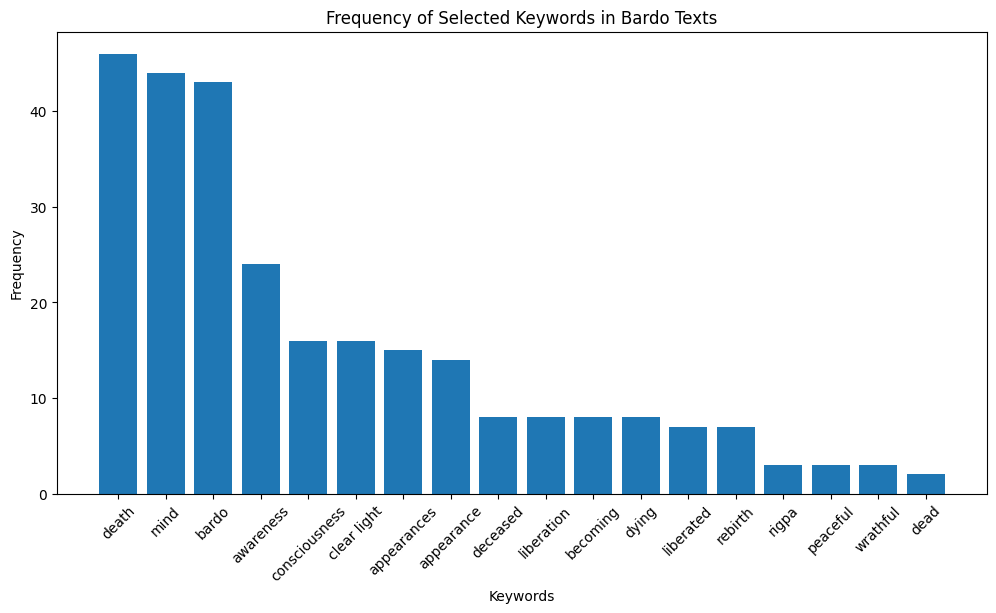

In [187]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

plt.bar(selected_keyword_df["keyword"],
        selected_keyword_df["count"])
selected_keyword_df["count"]

plt.xlabel("Keywords")
plt.ylabel("Frequency")
plt.title("Frequency of Selected Keywords in Bardo Texts")
plt.xticks(rotation = 45)

plt.show()


This bar chart shows the frequency of selected keywords in the bardo dataset. The most frequent keywords are “death” (46), “mind” (44), and “bardo” (39). This result suggests that the selected texts are strongly centered on three major ideas: the process of death, the role of the mind, and the intermediate state. These three words form the conceptual core of the dataset.

The high frequency of “death” confirms that these texts are directly concerned with dying and the end of ordinary life. However, the strong presence of “mind” shows that death is not described only as a physical event. Instead, the texts repeatedly connect death with mental or spiritual experience. This is further supported by the appearance of related terms such as “awareness” (24), “consciousness” (16), “clear light” (16), and “rigpa” (3). Together, these terms suggest that the process of dying is also understood as a moment of recognition, awareness, and possible spiritual transformation.

The frequency of “bardo” (39) also shows that the dataset is focused on the intermediate state. When combined with “bardos” (4), the bardo-related vocabulary appears 43 times. This supports the idea that the texts do not treat death as a single moment. Instead, death is described as part of a transitional process that continues through different intermediate states.

Another important pattern is the relationship between liberation and rebirth. The words “liberation” (8) and “liberated” (7) appear 15 times in total. The words “rebirth” (7) and “becoming” (8) also appear 15 times in total. This balance is important for my research question. It suggests that the bardo is represented as a space of possibility: it can lead to liberation if awareness is recognized, or to rebirth through the bardo of becoming.

The chart also includes visual and experiential terms, such as “appearance” (14), “appearances” (15), “peaceful” (3), and “wrathful” (3). These words suggest that bardo is not only described as an abstract state, but also as an experience filled with appearances and visionary forms. Although “peaceful” and “wrathful” appear less frequently, their presence still points to the importance of bardo visions and deity imagery in Tibetan Buddhist descriptions of the intermediate state.

Overall, this chart supports my main research question by showing that the selected bardo texts describe dying as a transition rather than simply an ending. The most frequent terms connect death with mind, awareness, bardo, liberation, and rebirth. This suggests that in these texts, death is not only a biological event. It is also a spiritual process in which the mind may either recognize its nature and attain liberation, or continue toward rebirth.

### Thematic Frequency Analysis ###

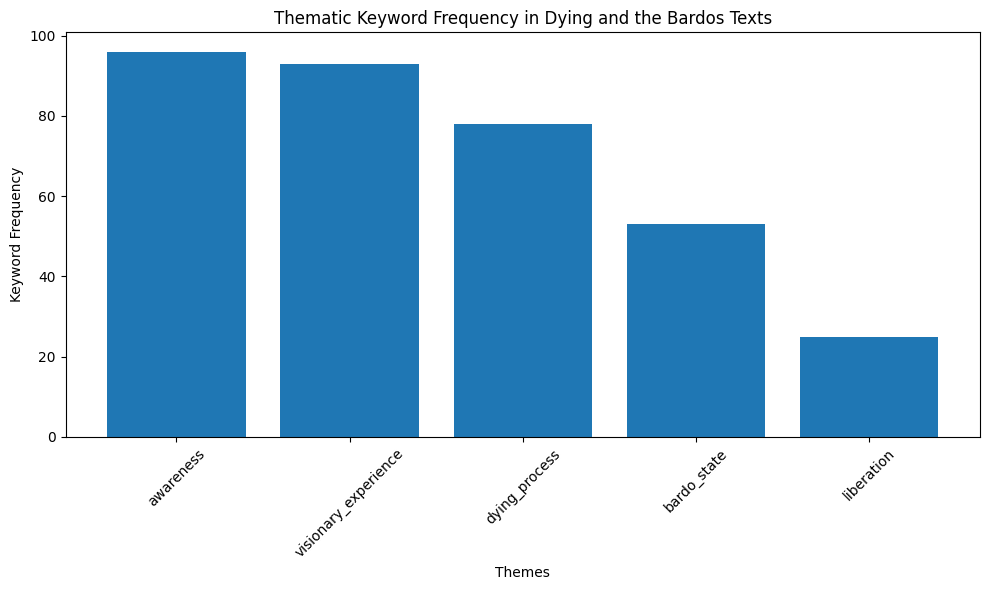

In [200]:
def count_keyword(text, term):
    text = text.lower()
    term = term.lower()
    pattern = r'\b' + re.escape(term) + r'\b'
    return len(re.findall(pattern, text))

theme_keywords = {"dying_process":
                    ["death", "dying", "deceased", "die", "dissolution"],
                  "bardo_state":
                     ["bardo", "bardos", "intermediate", "transitional", "between"],
                  "awareness":
                     ["awareness", "consciousness", "mind", "rigpa", "recognition", "recognize"],
                  "liberation":
                     ["liberation", "liberated", "awakening", "enlightenment", "realization", "realize"],
                  "visionary_experience":
                     ["vision", "visions", "experience", "experiences", "appearance", "appearances", "clear light", "sound", "deity", "deities", "peaceful", "wrathful"]}

thematic_freq_results = []

for theme, keywords in theme_keywords.items():
    total_count = 0
        
    for keyword in keywords:
        keyword_count = dataframe["normalized_text"].apply(lambda text: count_keyword(text, keyword)).sum()

        total_count += keyword_count

        thematic_freq_results.append({"theme": theme,
                              "keyword": keyword,
                              "count": keyword_count})    

theme_freq_df = pd.DataFrame(thematic_freq_results)
theme_freq_df.sort_values(by = "count", ascending = False).head(30)

theme_summary_df = (theme_freq_df
                    .groupby("theme")["count"]
                    .sum()
                    .reset_index()
                    .sort_values(by = "count", ascending = False))


plt.figure(figsize=(10, 6))

plt.bar(theme_summary_df["theme"], 
        theme_summary_df["count"])

plt.xticks(rotation=45)
plt.xlabel("Themes")
plt.ylabel("Keyword Frequency")
plt.title("Thematic Keyword Frequency in Dying and the Bardos Texts")

plt.tight_layout()
plt.show()

This thematic frequency chart shows which larger conceptual themes are most visible in the selected bardo texts. Instead of counting only individual words, I grouped related keywords into broader categories, such as awareness, visionary experience, dying process, bardo state, rebirth and becoming, and liberation.

The most frequent theme is “awareness.” This category includes words such as “mind,” “consciousness,” “awareness,” “rigpa,” “recognition,” and “recognize.” Its high frequency suggests that the selected bardo texts do not describe death only as a physical event. Instead, they repeatedly frame death and the bardo through the condition of the mind. This supports the idea that dying is a moment in which awareness, recognition, or non-recognition becomes spiritually important.

The second most frequent theme is “visionary experience.” This category includes words such as “appearance,” “appearances,” “clear light,” “vision,” “deity,” “peaceful,” and “wrathful.” This result suggests that bardo is described as an experiential and visionary process. The intermediate state is not presented as empty or passive. Instead, it involves appearances, perceptions, lights, and possibly deity imagery. This pattern is important because it connects bardo with religious experience, not only with death.

The “dying_process” theme is also highly visible. This category includes words such as “death,” “dying,” “deceased,” “die,” and “dissolution.” Its high frequency confirms that the dataset is strongly focused on the process of dying. However, because “awareness” and “visionary_experience” are even more frequent, the chart suggests that dying is not treated as only biological decline. It is also connected to mental recognition and visionary experience.

The “bardo_state” theme appears in the middle range. This shows that the intermediate state is an important organizing concept, but the texts do not only repeat the word “bardo.” Instead, they explain bardo through other ideas, especially awareness, appearances, death, and transition.

The lower frequency of “rebirth_becoming” and “liberation” is also meaningful. These themes appear less often than awareness or dying, but they represent two possible outcomes of the bardo process. The bardo may lead to liberation if awareness is recognized, or to rebirth through the bardo of becoming if recognition does not occur. Therefore, even though these categories are less frequent, they are still central to the research question.

Overall, this chart supports my argument that the selected Tibetan Buddhist bardo texts describe death as a transitional process. The texts connect dying with awareness, visionary appearances, bardo states, liberation, and rebirth. This suggests that bardo is not simply a state after death, but a process in which the mind encounters the possibility of either liberation or continued rebirth.

## Word Frequency Analysis

In this section, I use word frequency analysis to identify the most common words in my dataset. This helps me get a general sense of the language used in the selected Tibetan Buddhist Bardo texts.

Before counting words, I clean the text by converting it to lowercase, removing punctuation, and removing common stop words. This allows me to focus on meaningful words related to bardo, death, dying, liberation, rebirth, awareness, and religious practice.

### Word Frequency

In [212]:
import re
from collections import Counter

words = all_text.split()

filtered_words = [word for word in words if word not in stopwords and len(word) > 2]

word_counts = Counter(filtered_words)

word_freq_df = pd.DataFrame(word_counts.items(), 
                            columns = ["word", "count"])

word_freq_df = word_freq_df.sort_values(by='count', ascending = False)

word_freq_df.head(30)

,word,count
123,death,46
15,mind,44
1,bardo,39
298,dissolves,35
21,body,32
111,pure,29
6,time,28
36,clear,27
37,light,25
70,awareness,24


In [213]:
word_freq_df.to_csv("word_frequency_results.csv", index=False)


The word frequency results show several important patterns in the selected bardo texts. The most frequent meaningful words include “death,” “mind,” “bardo,” “dissolves,” “body,” “clear,” “light,” “awareness,” “perception,” “wisdom,” “luminosity,” “consciousness,” and “appearances.” These words suggest that the selected texts describe death is presented as a process involving the body, the dissolution of elements, the mind, awareness, and possible liberation.

The frequent appearance of words such as “death,” “dissolves,” “body,” “wind,” “water,” and “element” points to the dying process itself. These terms suggest that the texts pay close attention to the physical and experiential stages of dying. At the same time, words such as “mind,” “awareness,” “consciousness,” “wisdom,” “luminosity,” “clear,” and “light” show that the dying process is also connected to spiritual recognition. This supports my research question because the texts seem to frame dying as a moment when awareness or liberation may become possible.

The word “bardo” also appears frequently, which confirms that the dataset is focused on the intermediate state. Other words such as “state,” “experience,” “appearances,” “arise,” and “dharmatā” suggest that bardo is described as a series of experiences or appearances. In this sense, the frequency results suggest that bardo functions as a transitional process between death, awareness, liberation, and possibly rebirth.


### Normalize Frequency ###

In [223]:
dataframe["word_count"] = dataframe["normalized_text"].apply(lambda text: len(text.split()))

dataframe[["id", "title", "theme_keyword", "word_count"]].head()

for theme, keywords in theme_keywords.items():
    dataframe[theme + "_count"] = dataframe["normalized_text"].apply(
            lambda text: sum(count_keyword(text, keyword) for keyword in keywords))

for theme in theme_keywords.keys():
    dataframe[theme + "_per_1000_words"] = (dataframe[theme + "_count"] / dataframe["word_count"] * 1000)

dataframe = dataframe.fillna(0)

dataframe[["id", "title", "theme_keyword", "word_count"] +
          [theme + "_per_1000_words" for theme in theme_keywords.keys()]].head()

,id,title,theme_keyword,word_count,dying_process_per_1000_words,bardo_state_per_1000_words,awareness_per_1000_words,liberation_per_1000_words,visionary_experience_per_1000_words
0,T01_S01,The Root Verses on the Six Bardos,bardo of this life,64,0.000000,15.625000,15.625000,15.62500,0.000000
1,T01_S02,The Root Verses on the Six Bardos,dream bardo,57,0.000000,17.543860,17.543860,17.54386,17.543860
2,T01_S03,The Root Verses on the Six Bardos,samādhi bardo,64,0.000000,15.625000,0.000000,0.00000,0.000000
3,T01_S04,The Root Verses on the Six Bardos,bardo of dying,62,16.129032,16.129032,16.129032,0.00000,0.000000
4,T01_S05,The Root Verses on the Six Bardos,bardo of dharmatā,59,0.000000,33.898305,16.949153,0.00000,50.847458



This table shows the normalized frequency of each thematic category in every section of the dataset. Because the sections are not the same length, raw keyword counts can be misleading. A longer section may naturally contain more keywords simply because it has more words. To make the sections more comparable, I calculate the frequency of each theme per 1000 words.

For example, if a section has 64 words and one bardo-related keyword appears in it, the normalized frequency is 15.625 per 1000 words. This does not mean that the word appears 15 times in the section. Instead, it shows the density of that theme after adjusting for text length.

The first few rows show that different bardo sections emphasize different themes. The “bardo of this life” and “dream bardo” sections include bardo-related, awareness-related, and liberation-related vocabulary. The “bardo of dying” section includes dying process, bardo state, and awareness vocabulary, which suggests that this section connects physical death with the condition of the mind. The “bardo of dharmatā” section has especially high bardo_state and visionary_experience scores, suggesting that this section focuses on appearances, experience, and visionary or luminous phenomena.

This normalized analysis helps me move beyond simple word counts. It shows which themes are especially dense in particular sections. This supports my research question because it suggests that the bardo texts describe dying as a sequence of different stages. Some sections emphasize death and dissolution, while others emphasize awareness, visionary experience, liberation, or rebirth.

### Strongest Theme by Section Keyword ###

In [224]:
theme_per_1000_cols = [theme + "_per_1000_words" for theme in theme_keywords.keys()]

section_theme_df = (dataframe
                    .groupby("theme_keyword")[theme_per_1000_cols]
                    .mean()
                    .reset_index())

section_theme_df["strongest_theme"] = section_theme_df[theme_per_1000_cols].idxmax(axis=1)

section_theme_df["strongest_theme"] = section_theme_df["strongest_theme"].str.replace("_per_1000_words", "")

section_theme_df[["theme_keyword", "strongest_theme"]]


,theme_keyword,strongest_theme
0,aspiration prayer,awareness
1,awareness,awareness
2,bardo (divisions),bardo_state
3,bardo (general),awareness
4,bardo of becoming,bardo_state
5,bardo of dharmatā,visionary_experience
6,bardo of dying,dying_process
7,bardo of this life,bardo_state
8,clear light,awareness
9,dissolution,visionary_experience


This table shows the strongest thematic category for each section keyword in the dataset. I calculated the normalized frequency of each theme per 1000 words, grouped the results by `theme_keyword`, and identified which theme had the highest average score for each type of section.

The results show that different bardo sections emphasize different themes. Sections such as “bardo of dying” and “dying” are dominated by the `dying_process` theme, which makes sense because these sections focus on death, dying, and dissolution. Sections such as “dream bardo,” “samādhi bardo,” “bardo of this life,” and “bardo of becoming” are dominated by the `bardo_state` theme, suggesting that these sections are organized around different intermediate states.

The “bardo of dharmatā” section is dominated by `visionary_experience`. This is important because the dharmatā bardo is often described through appearances, lights, visions, and experiences. This result supports the idea that the bardo is not only an abstract state after death, but also an experiential and visionary process.

Several sections are dominated by `awareness`, including “aspiration prayer,” “bardo (general),” “clear light,” “phowa,” “practice,” and “rebirth.” This suggests that many sections frame the bardo process through the mind, awareness, recognition, or consciousness. This is significant for my research question because it shows that the transition from dying to liberation or rebirth is not only physical. It is also connected to recognition and mental awareness.

Some results are more surprising. For example, the section labeled “liberation” is dominated by `dying_process`, and “rebirth” is dominated by `awareness`. This does not mean that liberation or rebirth are unimportant. Instead, it suggests that these sections may discuss liberation and rebirth through the language of dying, awareness, and recognition. It also shows why close reading is necessary: the strongest theme in a section does not always match the section label directly.

Overall, this table supports my main argument that the selected bardo texts describe death as a multi-stage transition. Some stages emphasize dying and dissolution, some emphasize bardo states, some emphasize visionary appearances, and others emphasize awareness. Together, these patterns suggest that bardo is represented as a process that may lead either to liberation through recognition or to continued rebirth.

## TF-IDF Analysis

In this section, I use TF-IDF to identify distinctive terms in different sections of the bardo texts. Word frequency shows which words appear most often overall, but TF-IDF helps identify which words are especially important or distinctive in a specific section.

This is useful for my project because different bardo sections may emphasize different ideas. For example, sections about dying may emphasize dissolution and death, while sections about dharmatā may emphasize clear light, appearances, or awareness. TF-IDF allows me to compare sections more carefully instead of only counting the most common words across the whole dataset.

In [268]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

dataframe["cleaned_text"] = dataframe["cleaned_text"].fillna("")

vectorizer = TfidfVectorizer(stop_words = "english",
                             ngram_range = (1, 2),
                             max_features = 100)

tfidf_matrix = vectorizer.fit_transform(dataframe["cleaned_text"])

feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(),
                        columns = feature_names)

tfidf_df.head()

def get_top_tfidf_terms(row, feature_names, top_n=5):
    top_indices = row.sort_values(ascending=False).head(top_n).index
    return list(top_indices)

dataframe["top_tfidf_terms"] = tfidf_df.apply(lambda row: get_top_tfidf_terms(row,
                                                                              feature_names, 
                                                                              top_n = 5),
                                                                              axis=1)

dataframe[["id", "title", "theme_keyword", "top_tfidf_terms"]].head(15)


,id,title,theme_keyword,top_tfidf_terms
0,T01_S01,The Root Verses on the Six Bardos,bardo of this life,"[path, life, time, abandon, dawning]"
1,T01_S02,The Root Verses on the Six Bardos,dream bardo,"[like, dawning, abandon, kyema, state]"
2,T01_S03,The Root Verses on the Six Bardos,samādhi bardo,"[delusion, dawning, abandon, kyema, meditation]"
3,T01_S04,The Root Verses on the Six Bardos,bardo of dying,"[dying, dawning, abandon, kyema, attachment]"
4,T01_S05,The Root Verses on the Six Bardos,bardo of dharmatā,"[natural, bardo, abandon, dawning, kyema]"
5,T01_S06,The Root Verses on the Six Bardos,bardo of becoming,"[rebirth, perception, abandon, dawning, kyema]"
6,T02_S01,Crucial Advice: A Complete Set of Instructions...,bardo of this life,"[wisdom, life, self, moment death, instructions]"
7,T02_S02,Crucial Advice: A Complete Set of Instructions...,dissolution,"[dying, dissolution, dissolve, elements, place]"
8,T02_S03,Crucial Advice: A Complete Set of Instructions...,clear light,"[dharmakāya, death, primordial, instant, ordin..."
9,T02_S04,Crucial Advice: A Complete Set of Instructions...,bardo of dharmatā,"[appearances, self, sky, state, clear light]"


In [304]:
tfidf_with_theme = tfidf_df.copy()
tfidf_with_theme["theme_keyword"] = dataframe["theme_keyword"]

theme_tfidf_df = tfidf_with_theme.groupby("theme_keyword").mean()

theme_tfidf_df.head()

top_terms_by_theme = {}

for theme in theme_tfidf_df.index:
    top_terms = (theme_tfidf_df.loc[theme]
                 .sort_values(ascending = False)
                 .head(8)
                 .index
                 .tolist())
    top_terms_by_theme[theme] = top_terms


top_terms_rows = []

for theme, terms in top_terms_by_theme.items():
    for rank, term in enumerate(terms, start=1):
        top_terms_rows.append({"theme_keyword": theme,
                               "rank": rank,
                               "tfidf_term": term})

top_terms_long_df = pd.DataFrame(top_terms_rows)

top_terms_long_df

,theme_keyword,rank,tfidf_term
0,aspiration prayer,1,pray
1,aspiration prayer,2,path
2,aspiration prayer,3,supreme
3,aspiration prayer,4,mind
4,aspiration prayer,5,pure
...,...,...,...
147,samādhi bardo,4,kyema
148,samādhi bardo,5,meditation
149,samādhi bardo,6,state
150,samādhi bardo,7,single


In [307]:

top_terms_long_df.to_csv("top_tfidf_terms_long.csv", index=False)

The TF-IDF results show which terms are most distinctive for each section or theme. This adds another layer to the word frequency analysis. While the frequency analysis showed that words such as “death,” “mind,” and “bardo” are common across the dataset, TF-IDF helps identify more specific terms that define particular parts of the bardo process.

For example, if “dissolution” appears as a high TF-IDF term in sections about dying, this suggests that the dying process is described through the breakdown of body and elements. If “clear light” or “appearances” appears strongly in sections about dharmatā, this suggests that those sections focus on visionary or luminous experience. If “becoming,” “rebirth,” or “karma” appears strongly in sections about becoming, this suggests that those sections focus on movement toward future birth.

In this way, TF-IDF helps answer my research question by showing that the transition from dying to liberation or rebirth is not described as one single event. Different sections emphasize different parts of the process: dissolution, awareness, visionary appearances, liberation, and rebirth.

## Co-occurrence Network Analysis

In this section, I use co-occurrence network analysis to examine relationships between key concepts in the selected bardo texts. While word frequency analysis shows which words appear most often, co-occurrence analysis shows which words appear together.

For this project, I define co-occurrence at the section level. This means that if two keywords appear in the same section of a text, they are counted as co-occurring once in that section. Each keyword will later become a node in the network, and each co-occurrence will become an edge between two nodes.

### Define Keywords and Find Which Keywords Appear in Each Section ###

In [308]:
from itertools import combinations
from collections import Counter

from matplotlib import text

cooccerence_words = ["bardo", 
    "death", "dying", "dead", "deceased",
    "dissolution",
    "liberation", "liberated",
    "awakening", "enlightenment", "realization",
    "rebirth", "becoming", "birth",
    "awareness", "mind", "consciousness", "rigpa",
    "recognition", "recognize",
    "clear light",
    "appearance", "appearances",
    "peaceful", "wrathful",
    "karma", "samsara"]

def words_in_text(text, keyword):
    pattern = r'\b' + re.escape(keyword) + r'\b'
    return re.search(pattern, text) is not None


dataframe["present_keywords"] = dataframe["normalized_text"].apply(lambda text: [
    keyword for keyword in cooccerence_words 
    if words_in_text(text, keyword)])

dataframe[["id", "title", "section", "present_keywords"]].head(20)

,id,title,section,present_keywords
0,T01_S01,The Root Verses on the Six Bardos,Bardo of This Life,"[bardo, mind]"
1,T01_S02,The Root Verses on the Six Bardos,Bardo of Dreams,"[bardo, realization, mind, clear light]"
2,T01_S03,The Root Verses on the Six Bardos,Bardo of Samādhi Meditation,[bardo]
3,T01_S04,The Root Verses on the Six Bardos,Bardo of Dying,"[bardo, dying, awareness]"
4,T01_S05,The Root Verses on the Six Bardos,Bardo of Dharmatā,"[bardo, awareness, peaceful, wrathful]"
5,T01_S06,The Root Verses on the Six Bardos,Bardo of Becoming,"[bardo, rebirth, becoming, mind, karma]"
6,T02_S01,Crucial Advice: A Complete Set of Instructions...,Bardo of This Life and Dzogchen View,"[bardo, death, awareness, mind]"
7,T02_S02,Crucial Advice: A Complete Set of Instructions...,Bardo of Dying and Elemental Dissolution,"[bardo, death, dying, dissolution]"
8,T02_S03,Crucial Advice: A Complete Set of Instructions...,Recognition of Clear Light and Liberation at D...,"[death, birth, mind, rigpa]"
9,T02_S04,Crucial Advice: A Complete Set of Instructions...,Bardo of Dharmatā and Appearances as Rigpa,"[awakening, enlightenment, rigpa, recognize, c..."


### Count Keyword Co-occurrences ###

In [309]:
cooccurrence_count = Counter()

for keywords in dataframe["present_keywords"]:
    unique_keywords = sorted(set(keywords))

    for pair in combinations(unique_keywords, 2):
        cooccurrence_count[pair] += 1

cooccurrence_df = pd.DataFrame([{"keyword_1": pair[0], "keyword_2": pair[1], "weight": count}
                                for pair, count in cooccurrence_count.items()])

cooccurrence_df = cooccurrence_df.sort_values(by = "weight", ascending = False)

cooccurrence_df.head(20)

,keyword_1,keyword_2,weight
25,bardo,death,12
26,death,mind,11
14,bardo,becoming,8
31,birth,death,7
24,awareness,mind,7
0,bardo,mind,6
88,appearances,bardo,6
64,bardo,liberation,6
6,awareness,bardo,6
77,consciousness,death,5


This co-occurrence table shows which selected keywords appear together most often in the same text sections. The `weight` column represents the number of sections in which two keywords co-occur. A higher weight means that the two concepts are more frequently connected across the dataset.

The strongest co-occurrence is between “bardo” and “death” with a weight of 12. This suggests that the selected texts repeatedly connect the intermediate state with death. This supports my research question because it shows that bardo is not treated as a separate or abstract idea, but as something directly connected to the process of dying.

The second strongest pair is “death” and “mind” with a weight of 11. This is especially important because it suggests that death is not described only as a physical event. Instead, the texts often connect death with the condition of the mind. This supports the idea that dying is also a mental and spiritual process.

Another important connection is “bardo” and “becoming” with a weight of 8. This suggests that the bardo is connected to the process that may lead toward rebirth. The pair “birth” and “death” also appears with a weight of 7, showing that the texts often place death within a cycle of birth, death, and rebirth.

The pair “awareness” and “mind” also appears frequently, with a weight of 7. This suggests that awareness and mind are closely related in these texts. Other pairs, such as “bardo” and “liberation,” “bardo” and “awareness,” and “bardo” and “appearances,” show that the intermediate state is connected not only to death and rebirth, but also to spiritual recognition and visionary experience.

Overall, this table supports my main argument that the selected bardo texts describe death as a transitional process. The strongest connections link bardo with death, mind, becoming, liberation, awareness, and appearances. This suggests that the bardo is represented as a space between death and rebirth, but also as a possible moment of recognition and liberation.

### Filter Weak Connections and Count How Often Each Keyword Appear in Sections ###

In [310]:
min_weight = 1

strong_cooccurrence_df = cooccurrence_df[
    cooccurrence_df["weight"] >= min_weight].copy()

keyword_section_count = Counter()

for keywords in dataframe["present_keywords"]:
    unique_keywords = set(keywords)
    for keyword in unique_keywords:
        keyword_section_count[keyword] += 1

keyword_section_df = pd.DataFrame(keyword_section_count.items(), 
                                        columns = ["keyword", "section_count"]
                                        ).sort_values(by = "section_count", ascending = False)    

keyword_section_df.head(30)

,keyword,section_count
0,mind,34
11,death,31
1,bardo,30
5,awareness,16
20,consciousness,11
3,clear light,11
15,appearances,11
21,appearance,9
14,birth,9
10,becoming,8


In [311]:
edge_list = strong_cooccurrence_df[["keyword_1", "keyword_2", "weight"]]

edge_list.head(30)

,keyword_1,keyword_2,weight
25,bardo,death,12
26,death,mind,11
14,bardo,becoming,8
31,birth,death,7
24,awareness,mind,7
0,bardo,mind,6
88,appearances,bardo,6
64,bardo,liberation,6
6,awareness,bardo,6
77,consciousness,death,5


In [312]:
cooccurrence_df.to_csv("co_occurrence_results.csv", index=False)
strong_cooccurrence_df.to_csv("strong_cooccurrence_results.csv", index=False)
keyword_section_df.to_csv("keyword_section_counts.csv", index=False)

This edge list shows the strongest keyword co-occurrence relationships in the dataset. Each row represents a connection between two keywords. The `weight` column shows how many text sections contain both keywords. In the later network visualization, each keyword will become a node, and each row in this table will become an edge between two nodes.

The strongest connection is between “bardo” and “death,” with a weight of 12. This means that these two terms appear together in 12 sections. This strongly supports the idea that the selected texts connect the intermediate state directly with the process of death.

The second strongest connection is between “death” and “mind,” with a weight of 11. This is important because it suggests that death is not described only as a physical event. Instead, the texts frequently connect death with the mind, consciousness, awareness, and recognition.

The connection between “bardo” and “becoming” has a weight of 8, and the connections between “bardo” and “birth,” “bardo” and “rebirth,” and “becoming” and “rebirth” also appear in the table. These connections suggest that bardo is linked to the movement toward future birth or rebirth. This supports the idea that bardo is a transitional state between death and another life.

The table also shows connections between “bardo” and “liberation,” “bardo” and “awareness,” and “bardo” and “recognize.” These pairs suggest that bardo is not only connected to rebirth, but also to the possibility of liberation through awareness or recognition.

Several pairs connect death with experiential or mental terms, such as “death” and “clear light,” “death” and “consciousness,” “death” and “dissolution,” and “death” and “dying.” These connections show that the texts describe death as a process involving dissolution, consciousness, and visionary or luminous experience.

Overall, this edge list supports my main research question. It shows that the selected bardo texts do not describe death as an isolated ending. Instead, death is connected to bardo, mind, awareness, liberation, becoming, and rebirth. This means that the bardo is represented as a transitional process that may lead either to liberation through recognition or to continued rebirth.

## Network Visualization



In [313]:
import networkx as nx
import plotly.graph_objects as go

G = nx.Graph()

for _, row in strong_cooccurrence_df.iterrows():
    G.add_edge(row["keyword_1"],
               row["keyword_2"],
               weight = row["weight"])
    

keyword_size_dict = dict(zip(keyword_section_df["keyword"], keyword_section_df["section_count"]))

for node in G.nodes():
    G.nodes[node]["section_count"] = keyword_size_dict.get(node, 1)

print("Number of nodes: ", G.number_of_nodes())
print("Number of edges: ", G.number_of_edges())

pos = nx.spring_layout(G, seed = 42, k = 0.8)

list(pos.items())[:5]





Number of nodes:  26
Number of edges:  166


[('bardo', array([-0.09655044,  0.14275365])),
 ('death', array([-0.14057154, -0.00065958])),
 ('mind', array([ 0.13370688, -0.18738419])),
 ('becoming', array([-0.44080755,  0.17798192])),
 ('birth', array([-0.23513566, -0.18435952]))]

In [314]:
import plotly.graph_objects as go

edge_x = []
edge_y = []
edge_hover_text = []
edge_widths = []
edge_traces = []

for edge in G.edges(data = True):
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    weight = edge[2]["weight"]

    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

    edge_widths.append(weight)

for edge in G.edges(data = True):
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    weight = edge[2]["weight"]

    edge_trace = go.Scatter(x = [x0, x1],
                            y = [y0, y1],
                            line = dict(width = 0.8 + weight * 0.3, color = "rgba(120,120,120,0.5)"),
                            hoverinfo = "text",
                            text = [f"{edge[0]} and {edge[1]}<br>Co-occurrence weight: {weight}"],
                            mode = "lines")
    edge_traces.append(edge_trace)


node_x = []
node_y = []
node_text = []
node_size = []
node_color = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

    section_count = G.nodes[node]["section_count"]
    connections = len(list(G.neighbors(node)))

    node_text.append(f"Keyword: {node}<br>"
                     f"Appears in sections: {section_count}<br>"
                     f"Number of connnections: {connections}")
    
    node_color.append(section_count)

node_trace = go.Scatter(x = node_x,
                        y = node_y,
                        mode = "markers+text",
                        text = list(G.nodes()),
                        textposition = "top center",
                        hoverinfo = "text",
                        hovertext = node_text,
                        marker = dict(size = 18,
                                      color = node_color,
                                      colorscale = "YlOrBr",
                                      showscale = True,
                                      colorbar = dict(title = "Section Count"),
                                      line = dict(width = 1, color = "black")),
                                      textfont=dict(size=12, color="black"))

fig = go.Figure()

for edge_trace in edge_traces:
    fig.add_trace(edge_trace)

fig.add_trace(node_trace)

fig.update_layout(
    title = "Co-occurrence Network of Bardo-related Keywords",
    title_x = 0.5,
    showlegend = False,
    hovermode = "closest",
    margin = dict(b = 20, l = 20, r = 20, t = 60),
    xaxis = dict(showgrid = False, zeroline = False, showticklabels = False),
    yaxis = dict(showgrid = False, zeroline = False, showticklabels = False),
    height = 800,
    plot_bgcolor="white",
    paper_bgcolor="white")

fig.show(config={"scrollZoom": True})



This co-occurrence network visualizes how selected keywords are connected across the bardo dataset. Each node represents a keyword, and each edge represents a co-occurrence relationship between two keywords in the same text section. The color of each node represents section count: darker nodes appear in more sections, while lighter nodes appear in fewer sections.

The most central nodes in the network are “bardo,” “death,” and “mind.” These nodes are darker and located near the center of the graph, which suggests that they appear across many sections and connect to many other concepts. This supports my earlier keyword frequency results, where “death,” “mind,” and “bardo” were also among the most frequent terms. Together, these results suggest that the selected texts describe the bardo through the relationship between death, the intermediate state, and the mind.

The network also shows that “bardo” is connected to terms such as “death,” “dying,” “becoming,” “liberation,” “birth,” “awareness,” and “appearances.” This is important for my research question because it suggests that bardo functions as a bridge between different stages and possibilities. It is not only connected to death, but also to becoming, birth, liberation, and awareness. In other words, bardo is represented as a transitional process rather than a single isolated state.

Another important pattern is the cluster around “mind,” “awareness,” “clear light,” “consciousness,” “recognize,” and “rigpa.” These terms suggest that the bardo process is closely connected to mental recognition and spiritual awareness. The presence of “clear light” and “rigpa” is especially important because these terms point to Dzogchen understandings of awareness and recognition. This supports the idea that dying can become a moment of possible liberation if the nature of mind is recognized.

The network also includes terms related to visionary and experiential aspects, such as “appearances,” “appearance,” “peaceful,” “wrathful,” and “awakening.” These terms appear toward the right side of the graph and connect with awareness-related terms. This suggests that bardo is not described as an empty or passive state. Instead, it is represented as a field of appearances, visions, and possible recognition.

The left side of the network includes terms such as “rebirth,” “becoming,” “karma,” and “liberated.” This part of the graph shows another possible direction of the bardo process. If recognition does not lead to liberation, the bardo may continue toward becoming and rebirth. This pattern is important because it visually supports the central tension in my research question: the transition from dying can lead either toward liberation or toward rebirth.

Overall, the network supports my main argument that the selected Tibetan Buddhist bardo texts describe death as a multi-stage transition. The graph does not show death as an isolated endpoint. Instead, death is connected to bardo, mind, awareness, appearances, liberation, becoming, and rebirth. This suggests that in these texts, the bardo is a space of possibility: it can become a moment of recognition and liberation, or it can continue into karmic becoming and rebirth.

## Reflection

This project helped me understand how Python can be used as a tool for humanities research. My original goal was to study Tibetan Buddhist bardo texts and explore how they describe the transition from dying to liberation or rebirth. Through word frequency analysis, thematic frequency analysis, normalized frequency analysis, and co-occurrence network analysis, I was able to identify patterns in the language of the selected texts.

One part that worked well was the keyword and thematic frequency analysis. The results showed that words such as “death,” “mind,” “bardo,” “awareness,” “clear light,” “consciousness,” and “appearances” appeared frequently in the dataset. This helped me see that these texts do not describe death only as a biological ending. Instead, they connect death with the mind, awareness, visionary experience, and the possibility of liberation or rebirth.

The normalized frequency analysis was also useful because the sections in my dataset were not the same length. If I only used raw word counts, longer sections would naturally have more keywords. By calculating frequency per 1000 words, I could compare different sections more fairly. This helped me see that different bardo sections emphasize different themes. For example, some sections focus more on the dying process, while others focus more on awareness, visionary experience, or bardo states.

The co-occurrence network was one of the most useful parts of the project. It allowed me to move beyond counting words and begin thinking about relationships between concepts. The network showed that “bardo,” “death,” and “mind” were central nodes connected to many other terms. It also showed connections between dying, awareness, liberation, becoming, and rebirth. This supports my main research question by suggesting that the selected texts describe death as a transitional process rather than a single endpoint.

However, several parts of the project were challenging. One challenge was cleaning the text. Some words appeared in different forms, such as “appearance” and “appearances,” or “liberation” and “liberated.” These related words were sometimes counted separately, which may have affected the results. Another challenge was choosing keywords and themes. My categories, such as “awareness,” “dying_process,” and “visionary_experience,” were based on my own interpretation. If I chose different keywords, the results might look different.

Another limitation is that co-occurrence does not automatically prove meaning. If two words appear in the same section, this only shows textual closeness. It does not prove that the words have a direct doctrinal relationship. For example, a connection between “death” and “liberation” in the network suggests that they appear near each other, but I still need close reading to understand how the text explains that relationship. For this reason, I treat the network as a starting point for interpretation, not as final proof.

I also learned that building a dataset is itself an interpretive process. I had to decide which texts to include, how to divide them into sections, and which parts of the texts were most relevant to my research question. These choices shaped the final analysis. This reminded me that data is not neutral. Even before running Python code, human decisions already influence what the project can show.

Overall, this project helped me become more comfortable with Python and with digital humanities methods. I learned how to load and clean a dataset, count word frequencies, group keywords into themes, normalize frequencies, and create a co-occurrence network visualization. More importantly, I learned that computational methods can help reveal patterns in religious texts, but they cannot replace humanistic interpretation. In this project, Python helped me see that the selected bardo texts connect dying with awareness, appearances, liberation, and rebirth. At the same time, close reading remains necessary to explain what these connections mean within Tibetan Buddhist thought.